In [2]:
import warnings 
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd 
cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'annual_inc', 'loan_status', 'issue_d', 'dti', 'recoveries',
    'total_pymnt', 'out_prncp', 'funded_amnt_inv'
]
df=pd.read_csv(r"C:\Credit Risk & Expected Loss Analytics System\data\accepted_2007_to_2018Q4.csv",usecols=cols)

In [4]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,grade,sub_grade,annual_inc,issue_d,loan_status,dti,out_prncp,total_pymnt,recoveries
0,3600.0,3600.0,3600.0,36 months,13.99,C,C4,55000.0,Dec-2015,Fully Paid,5.91,0.00,4421.723917,0.0
1,24700.0,24700.0,24700.0,36 months,11.99,C,C1,65000.0,Dec-2015,Fully Paid,16.06,0.00,25679.660000,0.0
2,20000.0,20000.0,20000.0,60 months,10.78,B,B4,63000.0,Dec-2015,Fully Paid,10.78,0.00,22705.924294,0.0
3,35000.0,35000.0,35000.0,60 months,14.85,C,C5,110000.0,Dec-2015,Current,17.06,15897.65,31464.010000,0.0
4,10400.0,10400.0,10400.0,60 months,22.45,F,F1,104433.0,Dec-2015,Fully Paid,25.37,0.00,11740.500000,0.0


In [5]:
df.shape

(2260701, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   funded_amnt      float64
 2   funded_amnt_inv  float64
 3   term             object 
 4   int_rate         float64
 5   grade            object 
 6   sub_grade        object 
 7   annual_inc       float64
 8   issue_d          object 
 9   loan_status      object 
 10  dti              float64
 11  out_prncp        float64
 12  total_pymnt      float64
 13  recoveries       float64
dtypes: float64(9), object(5)
memory usage: 241.5+ MB


In [7]:
df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,annual_inc,dti,out_prncp,total_pymnt,recoveries
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260668e+06,2.260668e+06,2.260668e+06
mean,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,7.799243e+04,1.882420e+01,4.206891e+03,1.208256e+04,1.438791e+02
std,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,1.126962e+05,1.418333e+01,7.343239e+03,9.901383e+03,7.481640e+02
min,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,4.600000e+04,1.189000e+01,0.000000e+00,4.546458e+03,0.000000e+00
50%,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,6.500000e+04,1.784000e+01,0.000000e+00,9.329720e+03,0.000000e+00
75%,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,9.300000e+04,2.449000e+01,6.149940e+03,1.694087e+04,0.000000e+00
max,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.100000e+08,9.990000e+02,4.000000e+04,6.329688e+04,3.985955e+04


In [8]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'grade', 'sub_grade', 'annual_inc', 'issue_d', 'loan_status', 'dti',
       'out_prncp', 'total_pymnt', 'recoveries'],
      dtype='object')

In [9]:
df.isnull().sum()

loan_amnt            33
funded_amnt          33
funded_amnt_inv      33
term                 33
int_rate             33
grade                33
sub_grade            33
annual_inc           37
issue_d              33
loan_status          33
dti                1744
out_prncp            33
total_pymnt          33
recoveries           33
dtype: int64

In [10]:
#drop null values
df.dropna(subset=["loan_status","loan_amnt","grade","issue_d"],inplace=True)

In [11]:
#fill null values with the median value
df["dti"].fillna(df["dti"].median(),inplace=True)

In [12]:
df["annual_inc"].fillna(df["annual_inc"].median(),inplace=True)

In [13]:
df['recoveries'].fillna(0,inplace=True)

In [14]:
# Clean up int_rate — remove % sign if present and convert to float
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)

In [15]:
df['term'] = df['term'].str.extract('(\d+)').astype(int)

In [16]:
#Converting issue to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

In [17]:
# Extract issue year
df['issue_year'] = df['issue_d'].dt.year

print("Cleaned shape:", df.shape)
print(df.dtypes)

Cleaned shape: (2260668, 15)
loan_amnt                 float64
funded_amnt               float64
funded_amnt_inv           float64
term                        int64
int_rate                  float64
grade                      object
sub_grade                  object
annual_inc                float64
issue_d            datetime64[ns]
loan_status                object
dti                       float64
out_prncp                 float64
total_pymnt               float64
recoveries                float64
issue_year                  int32
dtype: object


In [18]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [27]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'grade', 'sub_grade', 'annual_inc', 'issue_d', 'loan_status', 'dti',
       'out_prncp', 'total_pymnt', 'recoveries', 'issue_year', 'default_flag',
       'EAD', 'recovery_rate', 'LGD', 'PD', 'ECL'],
      dtype='object')

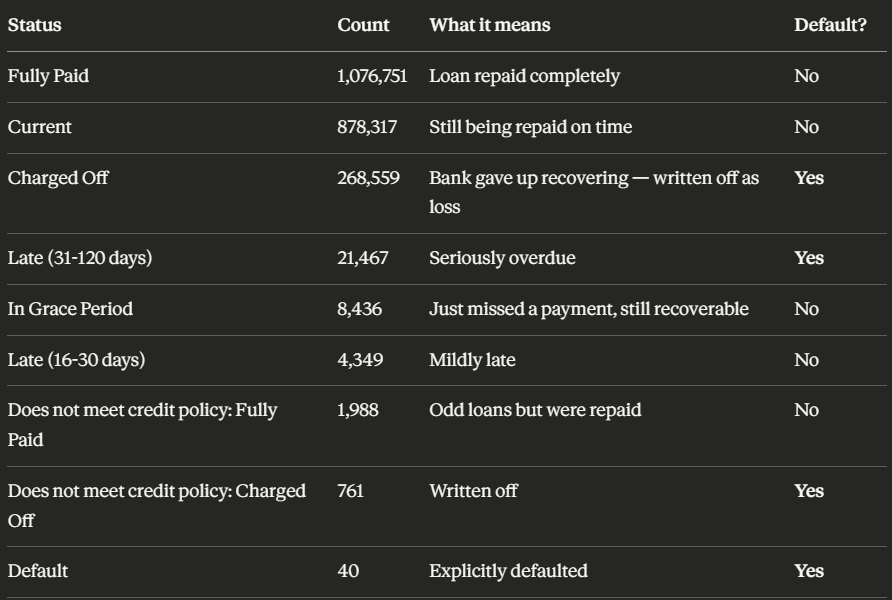

In [19]:
default_statuses = [
    'Charged Off',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
]

df['default_flag'] = df['loan_status'].isin(default_statuses).astype(int)

print(df['default_flag'].value_counts())
print(f"\nOverall default rate: {df['default_flag'].mean()*100:.2f}%")

default_flag
0    1969841
1     290827
Name: count, dtype: int64

Overall default rate: 12.86%


In [21]:
import numpy as np

In [22]:
# EAD = outstanding principal (what's still owed at time of default)
# For non-defaulted loans we use funded amount as proxy
df['EAD'] = np.where(df['default_flag'] == 1, df['out_prncp'], df['funded_amnt'])

print(df['EAD'].describe())

count    2.260668e+06
mean     1.313746e+04
std      9.917594e+03
min      0.000000e+00
25%      5.600000e+03
50%      1.120000e+04
75%      2.000000e+04
max      4.000000e+04
Name: EAD, dtype: float64


In [23]:
# LGD = 1 - recovery rate
# Recovery rate = how much was recovered as a fraction of total payment expected
df['recovery_rate'] = df['recoveries'] / df['funded_amnt']

# Cap recovery rate at 1 (can't recover more than what was lent)
df['recovery_rate'] = df['recovery_rate'].clip(0, 1)

df['LGD'] = 1 - df['recovery_rate']

print(df['LGD'].describe())

count    2.260668e+06
mean     9.910282e-01
std      4.084102e-02
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: LGD, dtype: float64


In [24]:
# PD = historical default rate per grade
pd_by_grade = df.groupby('grade')['default_flag'].mean().reset_index()
pd_by_grade.columns = ['grade', 'PD']
pd_by_grade['PD_pct'] = (pd_by_grade['PD'] * 100).round(2)

print(pd_by_grade)

  grade        PD  PD_pct
0     A  0.035878    3.59
1     B  0.086577    8.66
2     C  0.143618   14.36
3     D  0.203515   20.35
4     E  0.282846   28.28
5     F  0.364234   36.42
6     G  0.400066   40.01


In [25]:
# Merge PD back onto main dataframe
df = df.merge(pd_by_grade[['grade', 'PD']], on='grade', how='left')

# ECL = PD x LGD x EAD
df['ECL'] = df['PD'] * df['LGD'] * df['EAD']

print(f"Total Portfolio ECL: ${df['ECL'].sum():,.2f}")
print(f"Total Portfolio EAD: ${df['EAD'].sum():,.2f}")
print(f"ECL as % of Portfolio: {df['ECL'].sum()/df['EAD'].sum()*100:.2f}%")

Total Portfolio ECL: $3,745,432,785.25
Total Portfolio EAD: $29,699,444,649.43
ECL as % of Portfolio: 12.61%


In [26]:
ecl_by_grade = df.groupby('grade').agg(
    PD=('PD', 'first'),
    avg_LGD=('LGD', 'mean'),
    total_EAD=('EAD', 'sum'),
    total_ECL=('ECL', 'sum'),
    loan_count=('loan_amnt', 'count')
).reset_index()

ecl_by_grade['ECL_pct'] = (ecl_by_grade['total_ECL'] / ecl_by_grade['total_EAD'] * 100).round(2)
ecl_by_grade['PD'] = (ecl_by_grade['PD'] * 100).round(2)
ecl_by_grade['avg_LGD'] = (ecl_by_grade['avg_LGD'] * 100).round(2)

print(ecl_by_grade.to_string(index=False))

grade    PD  avg_LGD    total_EAD    total_ECL  loan_count  ECL_pct
    A  3.59    99.80 6.117935e+09 2.194973e+08      433027     3.59
    B  8.66    99.48 8.660604e+09 7.498120e+08      663557     8.66
    C 14.36    99.04 8.467060e+09 1.216018e+09      650053    14.36
    D 20.35    98.53 4.093028e+09 8.329906e+08      324424    20.35
    E 28.28    97.70 1.698435e+09 4.803962e+08      135639    28.28
    F 36.42    96.75 5.101140e+08 1.858011e+08       41800    36.42
    G 40.01    96.32 1.522683e+08 6.091732e+07       12168    40.01


In [28]:
import matplotlib.pyplot as plt

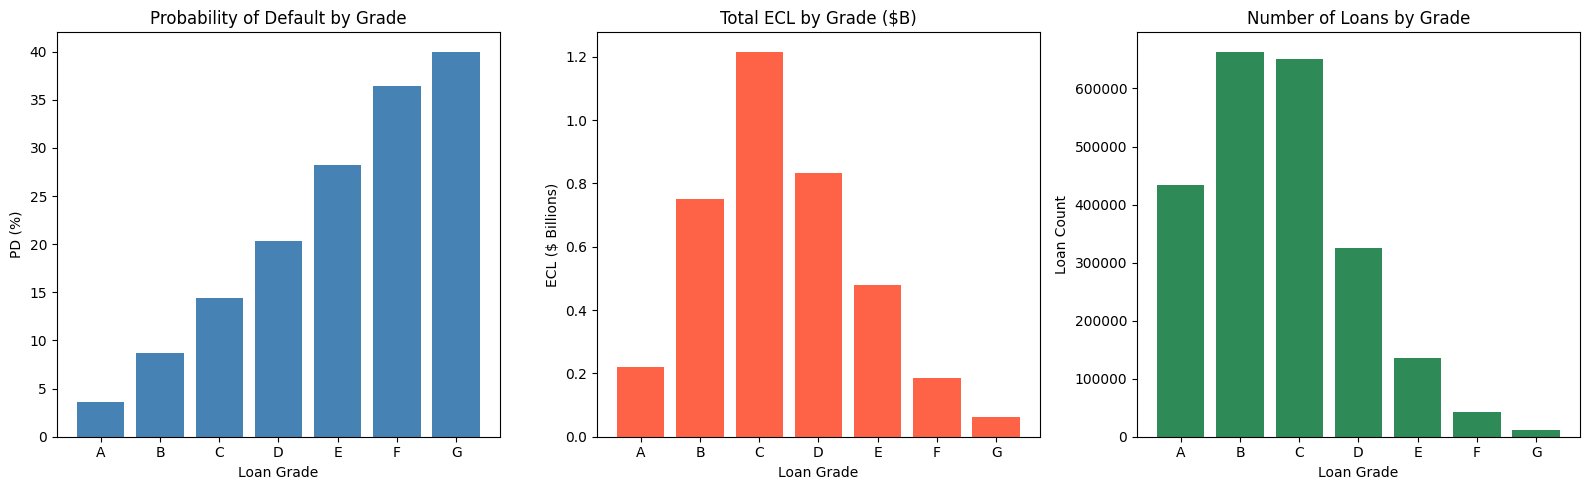

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 - PD by grade
axes[0].bar(ecl_by_grade['grade'], ecl_by_grade['PD'], color='steelblue')
axes[0].set_title('Probability of Default by Grade')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('PD (%)')

# Chart 2 - Total ECL by grade
axes[1].bar(ecl_by_grade['grade'], ecl_by_grade['total_ECL']/1e9, color='tomato')
axes[1].set_title('Total ECL by Grade ($B)')
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('ECL ($ Billions)')

# Chart 3 - Loan count by grade
axes[2].bar(ecl_by_grade['grade'], ecl_by_grade['loan_count'], color='seagreen')
axes[2].set_title('Number of Loans by Grade')
axes[2].set_xlabel('Loan Grade')
axes[2].set_ylabel('Loan Count')

plt.tight_layout()
plt.savefig("ecl_by_grade.png")
plt.show()

In [31]:
vintage = df.groupby('issue_year').agg(
    total_loans=('loan_amnt', 'count'),
    default_rate=('default_flag', 'mean'),
    total_ECL=('ECL', 'sum'),
    total_EAD=('EAD', 'sum')
).reset_index()

vintage['default_rate'] = (vintage['default_rate'] * 100).round(2)
vintage['ECL_pct'] = (vintage['total_ECL'] / vintage['total_EAD'] * 100).round(2)

print(vintage.to_string(index=False))

 issue_year  total_loans  default_rate    total_ECL    total_EAD  ECL_pct
       2007          603         26.20 6.100640e+05 3.362725e+06    18.14
       2008         2393         20.73 2.486743e+06 1.526708e+07    16.29
       2009         5281         13.69 5.820379e+06 4.421448e+07    13.16
       2010        12537         14.01 1.452616e+07 1.085404e+08    13.38
       2011        21721         15.18 2.954409e+07 2.150052e+08    13.74
       2012        53367         16.20 7.948268e+07 5.908392e+08    13.45
       2013       134814         15.60 2.228201e+08 1.652852e+09    13.48
       2014       235629         17.61 3.957077e+08 2.857732e+09    13.85
       2015       421095         18.32 6.866960e+08 5.209469e+09    13.18
       2016       434407         16.76 6.827727e+08 5.307602e+09    12.86
       2017       443579         10.63 7.496053e+08 5.924716e+09    12.65
       2018       495242          3.25 8.753609e+08 7.769846e+09    11.27


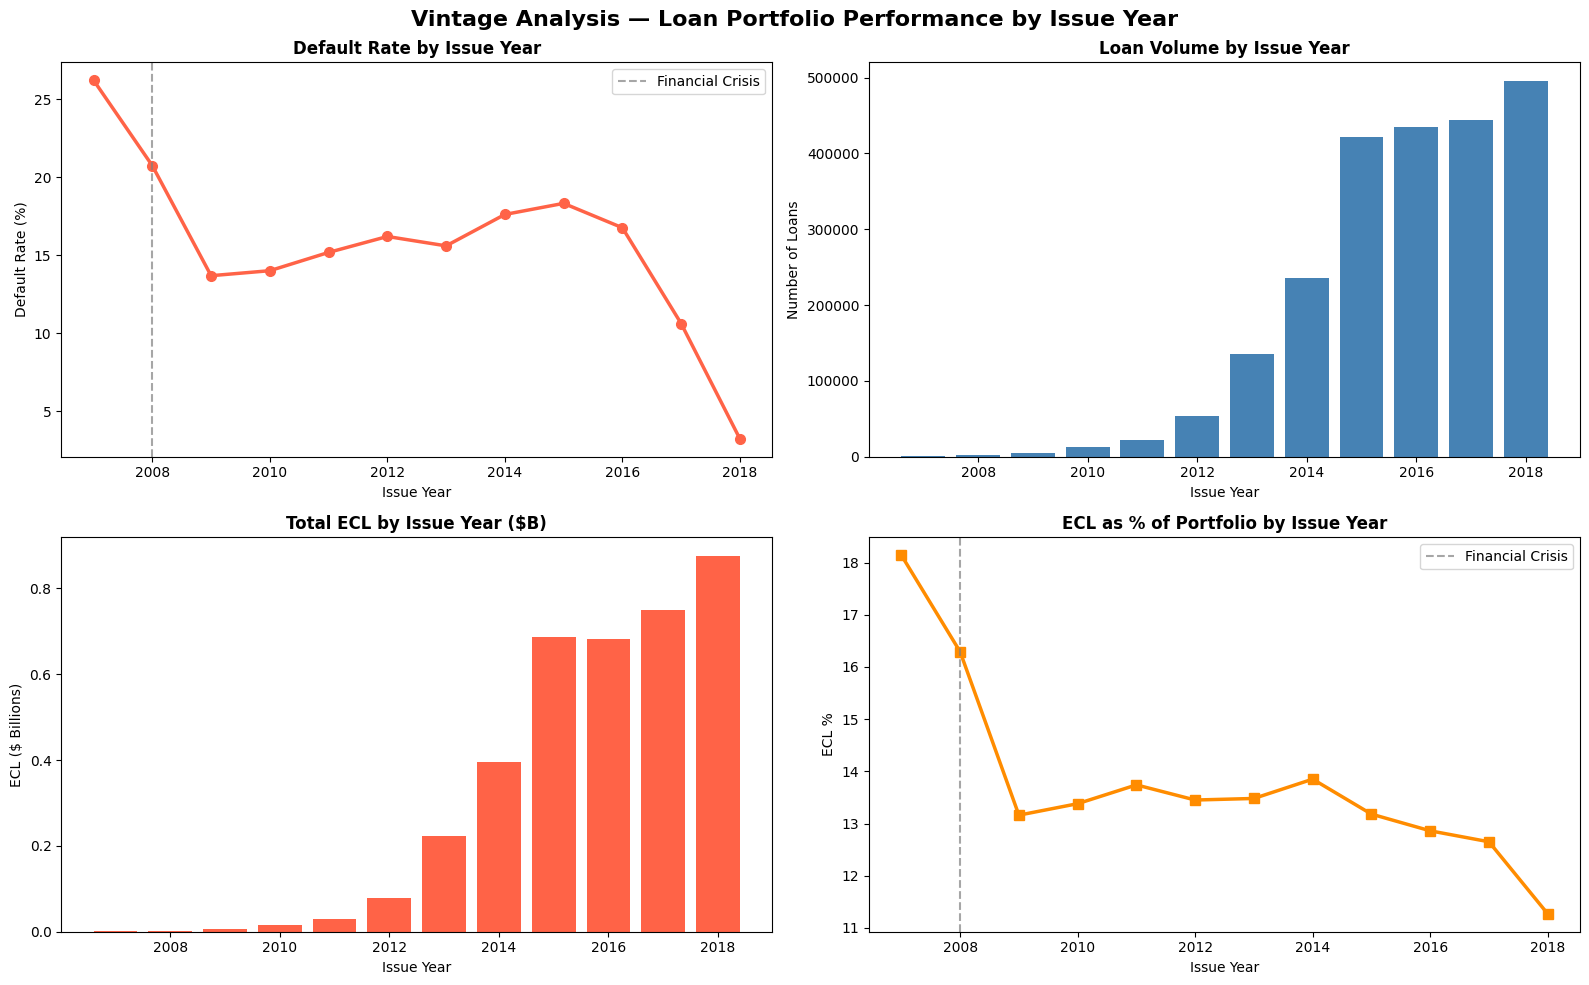

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Vintage Analysis — Loan Portfolio Performance by Issue Year', 
             fontsize=16, fontweight='bold')

# Chart 1 - Default rate by year
axes[0,0].plot(vintage['issue_year'], vintage['default_rate'], 
               marker='o', color='tomato', linewidth=2.5, markersize=7)
axes[0,0].set_title('Default Rate by Issue Year', fontweight='bold')
axes[0,0].set_xlabel('Issue Year')
axes[0,0].set_ylabel('Default Rate (%)')
axes[0,0].axvline(x=2008, color='gray', linestyle='--', alpha=0.7, label='Financial Crisis')
axes[0,0].legend()

# Chart 2 - Loan volume by year
axes[0,1].bar(vintage['issue_year'], vintage['total_loans'], color='steelblue')
axes[0,1].set_title('Loan Volume by Issue Year', fontweight='bold')
axes[0,1].set_xlabel('Issue Year')
axes[0,1].set_ylabel('Number of Loans')

# Chart 3 - Total ECL by year
axes[1,0].bar(vintage['issue_year'], vintage['total_ECL']/1e9, color='tomato')
axes[1,0].set_title('Total ECL by Issue Year ($B)', fontweight='bold')
axes[1,0].set_xlabel('Issue Year')
axes[1,0].set_ylabel('ECL ($ Billions)')

# Chart 4 - ECL% by year
axes[1,1].plot(vintage['issue_year'], vintage['ECL_pct'], 
               marker='s', color='darkorange', linewidth=2.5, markersize=7)
axes[1,1].set_title('ECL as % of Portfolio by Issue Year', fontweight='bold')
axes[1,1].set_xlabel('Issue Year')
axes[1,1].set_ylabel('ECL %')
axes[1,1].axvline(x=2008, color='gray', linestyle='--', alpha=0.7, label='Financial Crisis')
axes[1,1].legend()

plt.tight_layout()
plt.savefig("vintage_analysis.png")
plt.show()

In [34]:
import sqlite3

# Create database connection
conn = sqlite3.connect(r"C:\Credit Risk & Expected Loss Analytics System\data\credit_risk.db")

# Save cleaned dataframe to SQL table
df.to_sql('loans', conn, if_exists='replace', index=False)

print("Database created successfully")
print(f"Total rows saved: {len(df)}")

conn.close()

Database created successfully
Total rows saved: 2260668


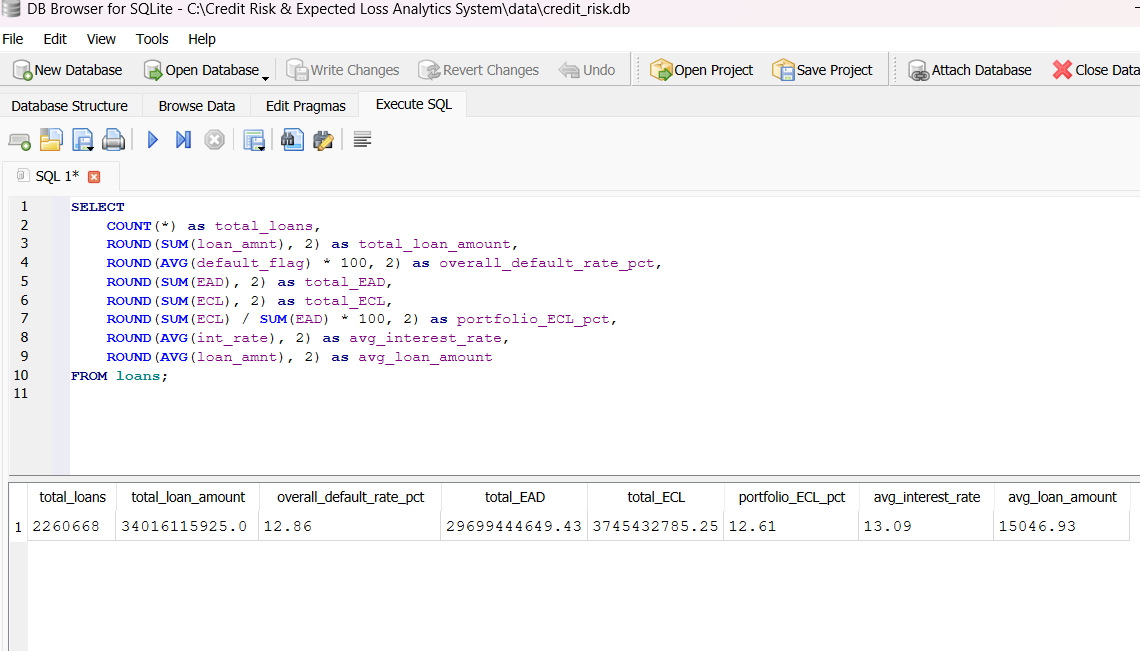

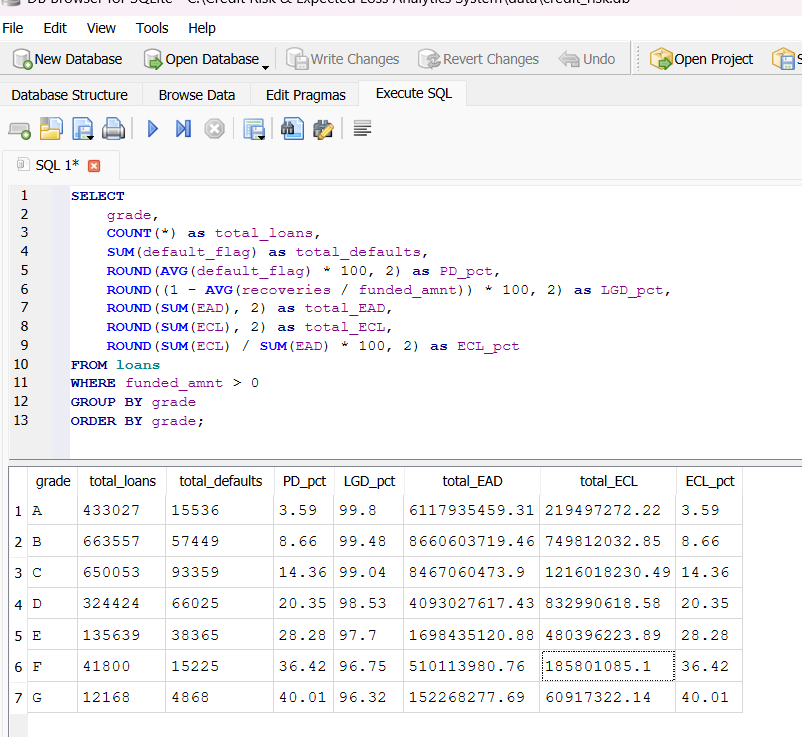

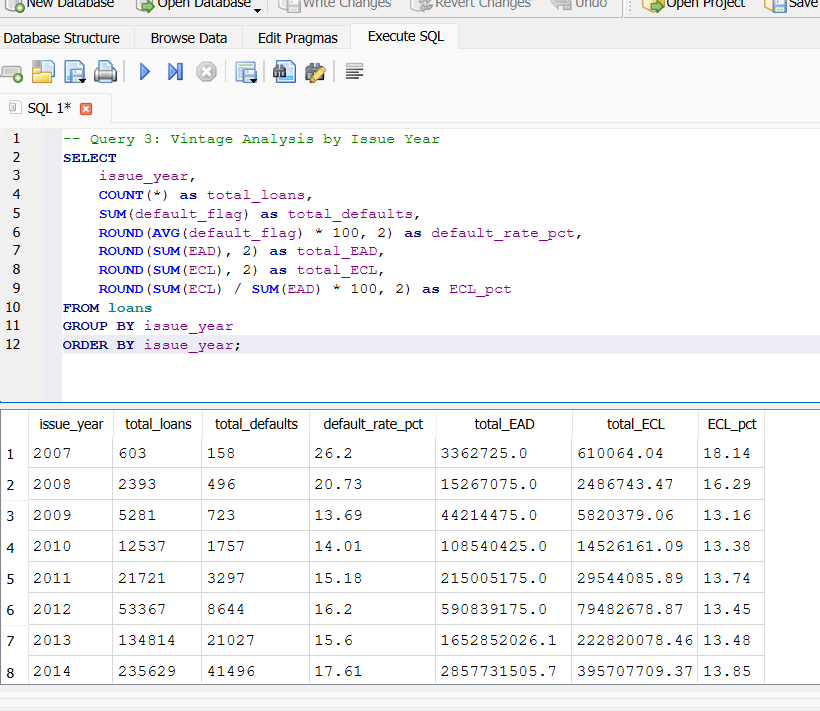

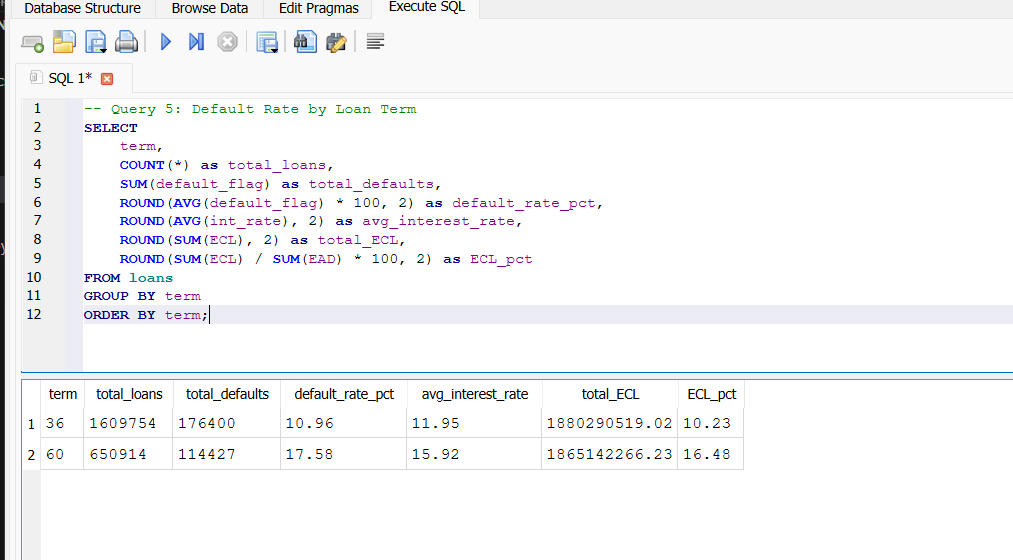

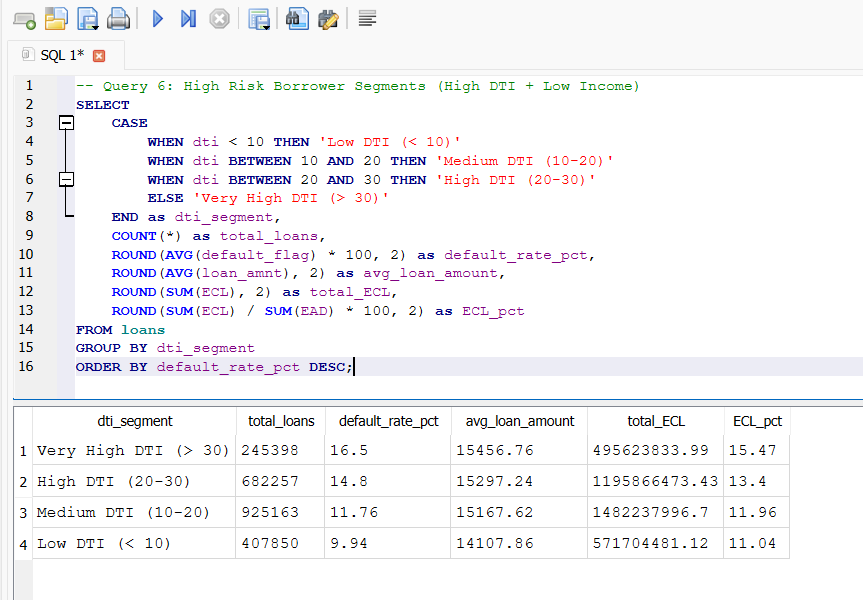

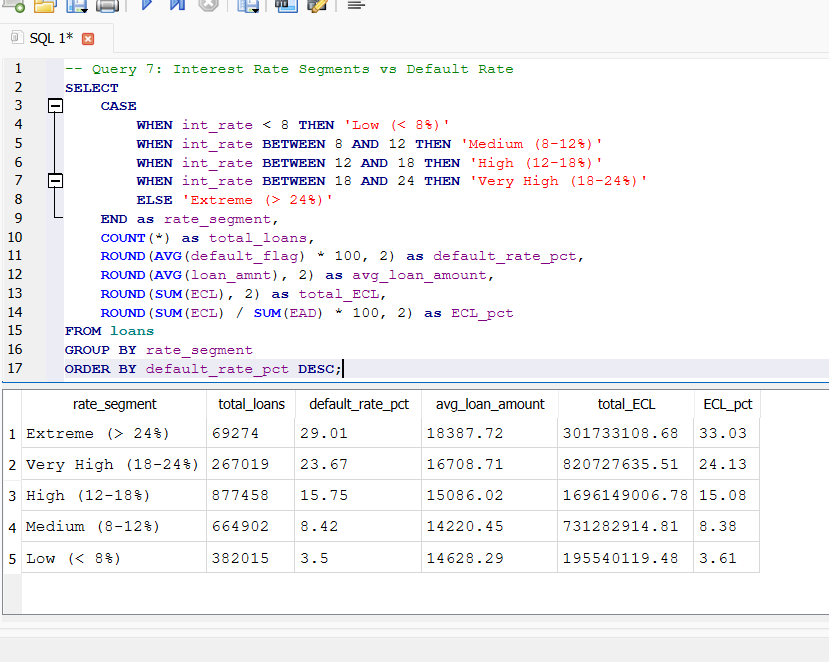

# STRESS TESTING

In [35]:
base_ecl = df['ECL'].sum()

scenarios = {
    'Base Case':       1.00,
    'Mild Stress':     1.25,
    'Moderate Stress': 1.50,
    'Severe Stress':   2.00,
    'Extreme Stress':  3.00
}

results = []
for scenario, multiplier in scenarios.items():
    stressed_ecl = base_ecl * multiplier
    results.append({
        'Scenario': scenario,
        'PD Multiplier': multiplier,
        'ECL ($B)': round(stressed_ecl / 1e9, 2),
        'ECL Increase ($B)': round((stressed_ecl - base_ecl) / 1e9, 2),
        'ECL % of Portfolio': round(stressed_ecl / df['EAD'].sum() * 100, 2)
    })

stress_df = pd.DataFrame(results)
print(stress_df.to_string(index=False))

       Scenario  PD Multiplier  ECL ($B)  ECL Increase ($B)  ECL % of Portfolio
      Base Case           1.00      3.75               0.00               12.61
    Mild Stress           1.25      4.68               0.94               15.76
Moderate Stress           1.50      5.62               1.87               18.92
  Severe Stress           2.00      7.49               3.75               25.22
 Extreme Stress           3.00     11.24               7.49               37.83


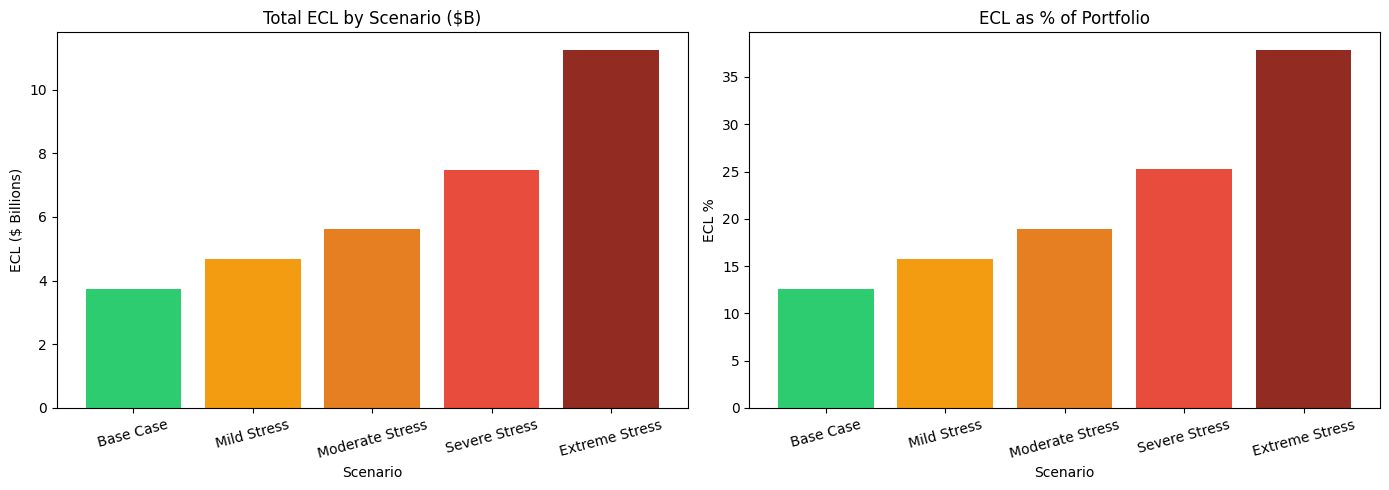

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#922b21']

axes[0].bar(stress_df['Scenario'], stress_df['ECL ($B)'], color=colors)
axes[0].set_title('Total ECL by Scenario ($B)')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('ECL ($ Billions)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(stress_df['Scenario'], stress_df['ECL % of Portfolio'], color=colors)
axes[1].set_title('ECL as % of Portfolio')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('ECL %')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("stress_testing.png")
plt.show()

In [39]:
# Export all data for Power BI dashboard

# ECL by grade
ecl_by_grade.to_csv(r"C:\Credit Risk & Expected Loss Analytics System\output\ecl_by_grade.csv", index=False)

# Vintage analysis
vintage.to_csv(r"C:\Credit Risk & Expected Loss Analytics System\output\vintage_analysis.csv", index=False)

# Stress scenarios
stress_df.to_csv(r"C:\Credit Risk & Expected Loss Analytics System\output\stress_scenarios.csv", index=False)

# Portfolio summary
portfolio_summary = pd.DataFrame([{
    'Total Loans': len(df),
    'Total EAD ($B)': round(df['EAD'].sum() / 1e9, 2),
    'Total ECL ($B)': round(df['ECL'].sum() / 1e9, 2),
    'Portfolio ECL %': round(df['ECL'].sum() / df['EAD'].sum() * 100, 2),
    'Overall Default Rate %': round(df['default_flag'].mean() * 100, 2),
    'Avg Interest Rate %': round(df['int_rate'].mean(), 2),
    'Avg Loan Amount ($)': round(df['loan_amnt'].mean(), 2)
}])
portfolio_summary.to_csv(r"C:\Credit Risk & Expected Loss Analytics System\output\portfolio_summary.csv", index=False)

print("All files exported successfully")

All files exported successfully
